In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
# pyodine path on the machine
pyodine_path = '/Users/jaklusmeyer/SONG/pyodine'

sys.path.append(pyodine_path)
if not hasattr(np, 'float'):
    np.float = float
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'bool'):
    np.bool = bool
if not hasattr(np, 'object'):
    np.object = object
if not hasattr(np, 'long'):
    np.long = int  # Python 3 doesn't have 'long'
import pyodine
import pyodine_model_observations
import utilities_song_apo as utilities

Pars = utilities.pyodine_parameters.Parameters()


/var/folders/rw/_tylhr6d7h5d4zl73ncpyn_80000gn/T/ipykernel_62335/3057381763.py:15: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'bool'):
/var/folders/rw/_tylhr6d7h5d4zl73ncpyn_80000gn/T/ipykernel_62335/3057381763.py:17: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'object'):
/var/folders/rw/_tylhr6d7h5d4zl73ncpyn_80000gn/T/ipykernel_62335/3057381763.py:19: FutureWarning: In the future `np.long` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, 'long'):


REMEMBER TO REMOVE TEMPLATE IF USING DECONVOLUTION!!!

In [2]:
from astropy.io import fits

# ====================================change these====================================================
night = "UT260321"
data_path = '/Users/jaklusmeyer/SONG/reduce/'

target_name = "HD185144"
ostar_name  = "HR3594"
#results_dir_name = "0007_sigdra_temp_results_v4_arcref" #where things will be saved, should be in data_path
results_dir_name = "0007_sigdra_temp_results_v5_o01_idealnight"

ostar_subdir         = "ostar4"
templatestar_subdir  = "templatestar"
sciencestar_subdir   = "sciencestar"

# ==================================== stay the same=============================================
data_base_dir = os.path.abspath(data_path)
night_dir = os.path.join(data_base_dir, night)

science_dir = os.path.join(night_dir, sciencestar_subdir)

def get_fits_files(directory, label, expect_i2=None):
    if not os.path.isdir(directory):
        raise ValueError(f"{label} is not a directory: {directory}")
    fits_files = sorted(
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.lower().endswith(".fits")
    )
    if len(fits_files) == 0:
        raise ValueError(f"No FITS files found in {label}: {directory}")
    if expect_i2 is not None:
        verified = []
        for fpath in fits_files:
            with fits.open(fpath) as hdul:
                h = hdul[0].header
                has_i2 = (h.get('FILTER', '') == 'iodine') or (h.get('I2POS', 0) > 0)
            if has_i2 == expect_i2:
                verified.append(fpath)
            else:
                print(f"  *** WRONG: {os.path.basename(fpath)} ***")
        fits_files = verified
    print(f"{label}: {len(fits_files)} file(s)")
    return fits_files

# === OBSERVATIONS: science star through I2 ===
obs_files = get_fits_files(science_dir, "Science (star+I2)", expect_i2=True)

# === TEMPLATE: output from hotstar_lsf notebook ===
plot_dir = os.path.join(data_base_dir, results_dir_name)
temp_file = os.path.join(plot_dir, "obs_temp_highsnr_test.h5")
print(f"Template file: {temp_file}")
print(f"Template exists: {os.path.isfile(temp_file)}")
temp_files = [temp_file] * len(obs_files)

# === OUTPUT PATHS ===
plot_dir_parent = os.path.join(plot_dir, "obs_results")

plot_dirs   = []
error_files = []
info_files  = []
res_files   = []

for obs_file in obs_files:
    base = os.path.splitext(os.path.basename(obs_file))[0]
    this_plot_dir = os.path.join(plot_dir_parent, base)
    os.makedirs(this_plot_dir, exist_ok=True)
    
    plot_dirs.append(this_plot_dir)
    error_files.append(os.path.join(this_plot_dir, "error.log"))
    info_files.append(os.path.join(this_plot_dir, "info.log"))
    res_files.append([
        os.path.join(this_plot_dir, f"{base}_res0.h5"),
        os.path.join(this_plot_dir, f"{base}_res1.h5"),
    ])

print(f"\nObservations to model: {len(obs_files)}")
print(f"Results directory: {plot_dir_parent}")

Science (star+I2): 60 file(s)
Template file: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/obs_temp_highsnr_test.h5
Template exists: True

Observations to model: 60
Results directory: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/obs_results


In [3]:
pyodine_model_observations.model_single_observation(
    utilities, Pars, obs_files[0], temp_files[0], 
    plot_dir=plot_dirs[0], res_names=res_files[0],
    error_log=error_files[0], info_log=info_files[0], live=False)


Branch: master
Hash: c2a71ac
---------------------------
Working on: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260222.0253.fits
Trying to load file: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260222.0253.fits
Detected multi-extension FITS format
Reversing arrays to ensure ascending wavelength
BVC from header: -3.86 km/s
Instrument is SONG/APO SONG!!!

Median flux of the observation: 5605
Loading template from file: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/obs_temp_highsnr_test.h5
Reversing iodine template wavelength array to ensure increasing order.

Order correction: 0

Measured velocity rel. to reference spectrum: -71.530 km/s
Template velocity: 29.569 km/s
Velocity guess: -101.100 km/s (relative to template)

(Barycentric velocity of observation: -3.860 km/s)
(Barycentric velocity of template: -2.273 km/s)


Barycentric redshift between template and observation: 
v = 1586.5349125364837, z = 5.29211082600511

  0% (2 of 650) |                        | Elapsed Time: 0:00:00 ETA:   0:00:33

Chunk 3:
(xb<=x[0]) failed for 1st keyword xb: curfit:xb=nan


  1% (7 of 650) |                        | Elapsed Time: 0:00:00 ETA:   0:00:37

Chunk 8:
(xb<=x[0]) failed for 1st keyword xb: curfit:xb=nan


...

Chunk 644: No Data! Returning LmfitResult with None.
Chunk 645: No Data! Returning LmfitResult with None.


 99% (647 of 650) |##################### | Elapsed Time: 0:01:31 ETA:   0:00:00

NaN value detected in oversampled model function.
<ParameterSet (values: 17)>
    cont_intercept  =  10043.94434885638
    cont_slope      =  2.5231349109106675
    iod_depth       =  1.0710761992795996
    lsf_left_1      =  4.047410124402832
    lsf_left_2      =  -7.572848287824744
    lsf_left_3      =  2.8614427670685636
    lsf_left_4      =  -3.265206121897228
    lsf_left_5      =  1.1886100259157257
    lsf_right1      =  2.588368667367878
    lsf_right2      =  -17.25984476384025
    lsf_right3      =  4.313297874027951
    lsf_right4      =  -0.8170585756719433
    lsf_right5      =  0.3523189893548748
    tem_depth       =  -0.5004887343932993
    velocity        =  -22474.145834906172
    wave_intercept  =  6331.848089525946
    wave_slope      =  0.015385531128293831
Evaluated LSF:
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan na

100% (650 of 650) |######################| Elapsed Time: 0:01:31 Time:  0:01:31



Number of chunks with no uncertainties: 1
Number of chunks with outliers: 0
Number of chunks with nan fitted red. Chi2: 83

Creating analysis plots...
NaN value detected in iodine function.
Chunk could not be plotted
Traceback (most recent call last):
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/plot_lib.py", line 62, in plot_chunkmodel
    sp = fit_results[chunk_nr].fitted_spectrum
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/fitters/base.py", line 45, in fitted_spectrum
    return self.model.eval_spectrum(self.chunk, self.params, chunk_ind=self.chunk_ind)
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/models/base.py", line 79, in eval_spectrum
    flux = self.eval(chunk, params, chunk_ind=chunk_ind, **kwargs)
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/models/spectrum.py", line 138, in eval
    tck = splrep(tem.wave * doppler, flux_tem, s=0)
  File "/Users/jaklusmeyer/miniconda/envs/pyodine_env/lib/python3.9/site-packages/scipy/interpolate/_fitpack_py.py", line 295, in sp

In [4]:
# Restore the RUN 1 fit results for the first observation
chunks, fit_results = pyodine.fitters.results_io.restore_results_object(
    utilities, res_files[0][1])


Trying to load file: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260222.0253.fits
Detected multi-extension FITS format
Reversing arrays to ensure ascending wavelength
BVC from header: -3.86 km/s
Instrument is SONG/APO SONG!!!
Loading template from file: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/obs_temp_highsnr_test.h5
Reversing iodine template wavelength array to ensure increasing order.
Total number of created chunks: 650 (in result file: 650)
Number of created chunks in order 0: 25
Chunk 2: No Data! Returning LmfitResult with None.
Chunk 3: No Data! Returning LmfitResult with None.
Chunk 4: No Data! Returning LmfitResult with None.
Chunk 5: No Data! Returning LmfitResult with None.
Chunk 8: No Data! Returning LmfitResult with None.
Chunk 9: No Data! Returning LmfitResult with None.
Chunk 12: No Data! Returning LmfitResult with None.
Chunk 20: No Data! Returning LmfitResult with None.
Chunk 25: No Data! Returning LmfitResult with No

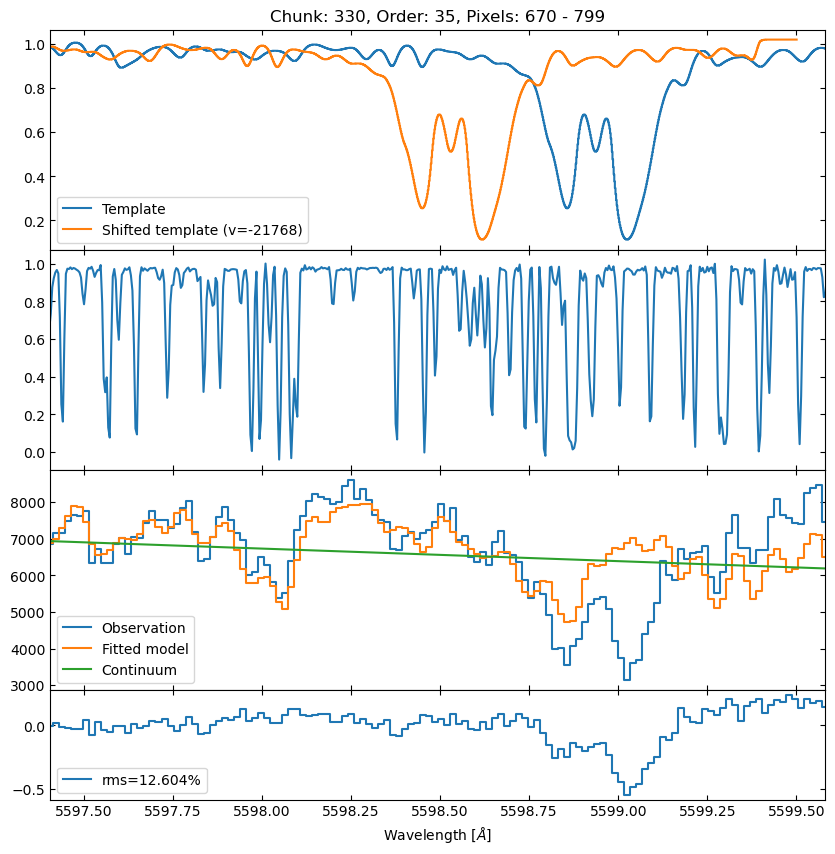

In [5]:
# Chunk index
chunk_ind = 330

pyodine.plot_lib.plot_chunkmodel(fit_results, chunks, chunk_ind, template=True, 
                                 show_plot=True)

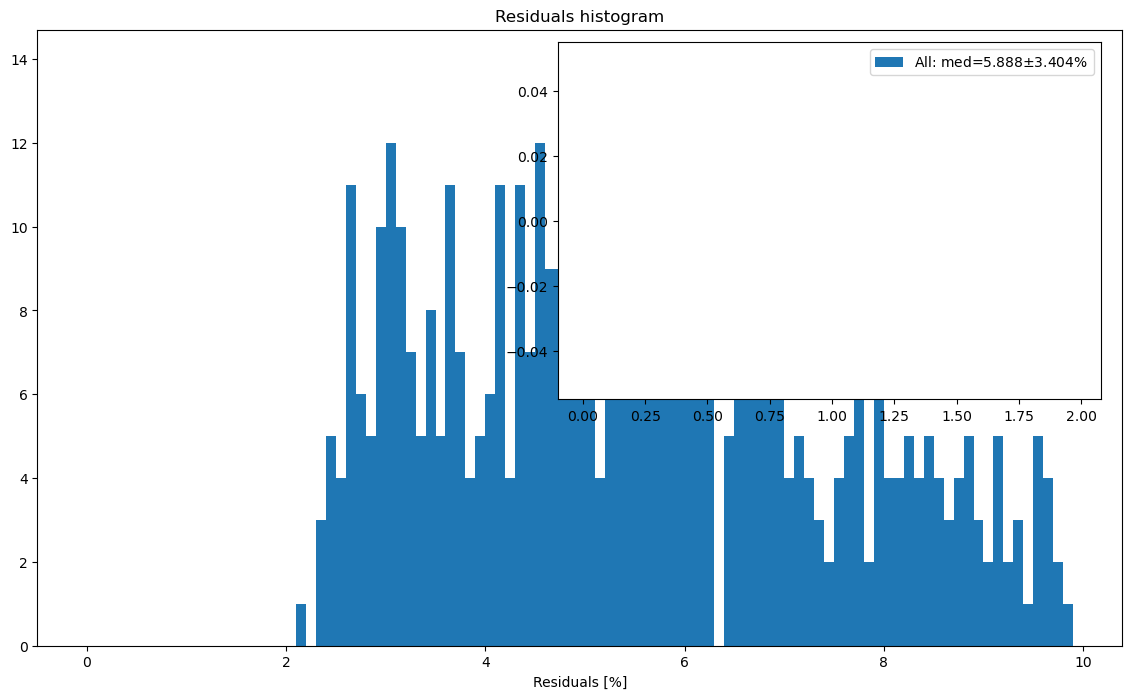

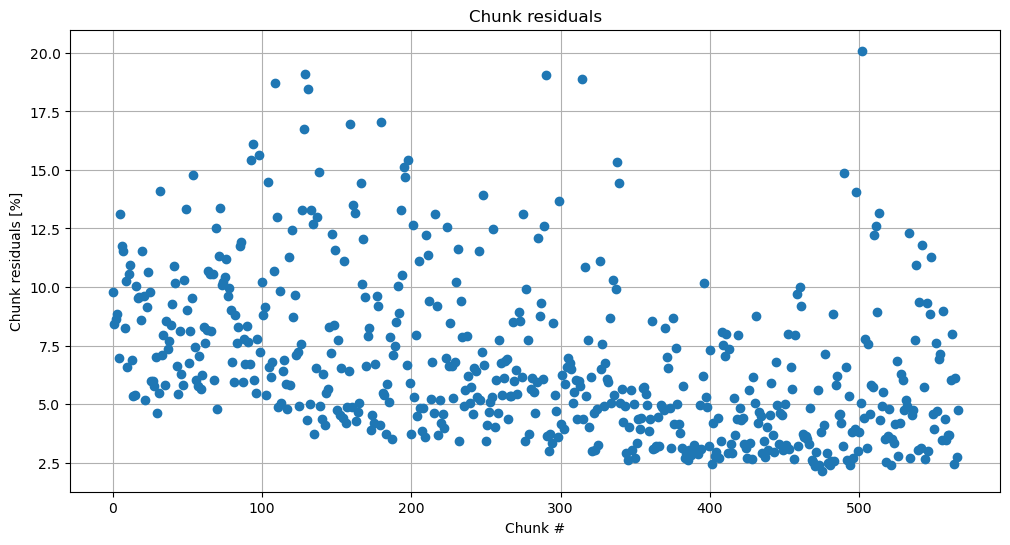

In [6]:
# Plot the histogram of residuals
residuals = pyodine.plot_lib.plot_residual_hist(fit_results, title='Residuals histogram', 
                                                show_plot=True)
# Plot the scatter of residuals
pyodine.plot_lib.plot_chunk_scatter(scatter=residuals, ylabel='Chunk residuals [%]', 
                                    title='Chunk residuals', show_plot=True)

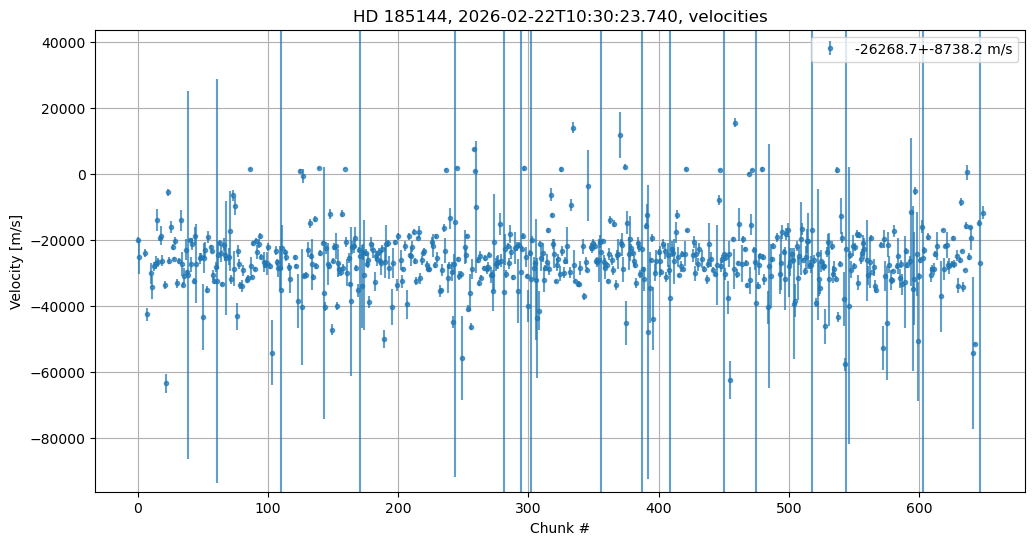

In [7]:
# Fetch observation info
star_name = chunks[0].observation.star.name
obs_date  = chunks[0].observation.time_start.value

# Fetch the velocities and and their fit uncertainties
velocities = np.array([r.params['velocity'] for r in fit_results])
vel_errors = [r.errors['velocity'] for r in fit_results]

# Compute robust mean and std
vel_med = pyodine.timeseries.misc.robust_mean(velocities)
vel_std = pyodine.timeseries.misc.robust_std(velocities)

# And plot (in constraint y-range)
pyodine.plot_lib.plot_chunk_scatter(
    errorbar=velocities, errorbar_yerr=vel_errors, errorbar_alpha=0.7, 
    errorbar_label='{:.1f}+-{:.1f} m/s'.format(vel_med, vel_std),
    yrange=(vel_med-8*vel_std, vel_med+8*vel_std),
    ylabel='Velocity [m/s]', title='{}, {}, velocities'.format(star_name, obs_date), 
    grid=True, show_plot=True
)

In [8]:
#run on multiple observations in the folder
pyodine_model_observations.model_multi_observations(
    utilities, Pars, obs_files[1:], temp_files[1:], 
    plot_dirs=plot_dirs[1:], res_files=res_files[1:], 
    error_files=error_files[1:], info_files=info_files[1:], quiet=False)

Reversing iodine template wavelength array to ensure increasing order.



Branch: master
Hash: c2a71ac
---------------------------
Working on: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260223.0251.fits
Trying to load file: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260223.0251.fits
Detected multi-extension FITS format

Branch: master
Hash: c2a71ac
---------------------------
Working on: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260224.0256.fits
Trying to load file: /Users/jaklusmeyer/SONG/reduce/UT260321/sciencestar/HD185144_ec_260224.0256.fits
Detected multi-extension FITS format
Reversing arrays to ensure ascending wavelength
BVC from header: -3.82 km/s
Instrument is SONG/APO SONG!!!

Median flux of the observation: 12734
Loading template from file: /Users/jaklusmeyer/SONG/reduce/0007_sigdra_temp_results_v5_o01_idealnight/obs_temp_highsnr_test.h5
Reversing arrays to ensure ascending wavelength
BVC from header: -3.77 km/s
Instrument is SONG/APO SONG!!!

Median flux of the observation: 6712
Lo

N/A% (0 of 650) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--


Constraining parameters for RUN 0


N/A% (0 of 650) |                        | Elapsed Time: 0:00:00 ETA:  --:--:--

...

Chunk 644: No Data! Returning LmfitResult with None.
Chunk 645: No Data! Returning LmfitResult with None.


 99% (647 of 650) |##################### | Elapsed Time: 0:01:28 ETA:   0:00:00

NaN value detected in oversampled model function.
<ParameterSet (values: 17)>
    cont_intercept  =  13272.355184927546
    cont_slope      =  -6.6546432774794635
    iod_depth       =  0.70877175400647
    lsf_left_1      =  4.896083623441465
    lsf_left_2      =  -18.980849408747616
    lsf_left_3      =  10.498027672420621
    lsf_left_4      =  -3.25299180467902
    lsf_left_5      =  0.13676676875253105
    lsf_right1      =  2.513426937096655
    lsf_right2      =  -7.083525433195591
    lsf_right3      =  1.2545293556112445
    lsf_right4      =  -3.815222356628529
    lsf_right5      =  0.3767237544228708
    tem_depth       =  -0.09202182101640141
    velocity        =  -26945.130995644762
    wave_intercept  =  6329.614873771787
    wave_slope      =  0.015893845049980357
Evaluated LSF:
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan 

100% (650 of 650) |######################| Elapsed Time: 0:01:28 Time:  0:01:28



Number of chunks with no uncertainties: 1
Number of chunks with outliers: 0
Number of chunks with nan fitted red. Chi2: 64

Creating analysis plots...
NaN value detected in iodine function.
Chunk could not be plotted
Traceback (most recent call last):
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/plot_lib.py", line 62, in plot_chunkmodel
    sp = fit_results[chunk_nr].fitted_spectrum
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/fitters/base.py", line 45, in fitted_spectrum
    return self.model.eval_spectrum(self.chunk, self.params, chunk_ind=self.chunk_ind)
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/models/base.py", line 79, in eval_spectrum
    flux = self.eval(chunk, params, chunk_ind=chunk_ind, **kwargs)
  File "/Users/jaklusmeyer/SONG/pyodine/pyodine/models/spectrum.py", line 138, in eval
    tck = splrep(tem.wave * doppler, flux_tem, s=0)
  File "/Users/jaklusmeyer/miniconda/envs/pyodine_env/lib/python3.9/site-packages/scipy/interpolate/_fitpack_py.py", line 295, in sp

In [9]:
#print the time this cell was run
import datetime
print("This cell was run at:", datetime.datetime.now())

This cell was run at: 2026-04-14 10:49:00.187416
